In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, make_scorer
from scipy.stats import uniform, randint
from xgboost import XGBClassifier

%pip install shap
import shap
import xgboost as xgb

In [3]:
file_path = "globalterrorismdb_0522dist_csv.csv"
data = pd.read_csv(file_path, sep=";", encoding="latin1", low_memory=False)
print(f"Original Dataset shape: {data.shape}")

Original Dataset shape: (209706, 135)


In [4]:
# 1) Filter: data between 1998 and 2017

data = data[data["iyear"].between(1998, 2017)]

In [5]:
# 2️) GTD-criteria

data = data[
    (data["crit1"] == 1) &
    (data["crit2"] == 1) &
    (data["crit3"] == 1)
]
print(f"Dataset shape after GTD-Filter: {data.shape}")

Dataset shape after GTD-Filter: (99492, 135)


In [6]:
# 3️) Target variable (casualty occurrence)

# drop observation with NaNs in nkill and nwound
data = data.dropna(subset=["nkill", "nwound", "nkillter", "nwoundte"])

data["casualties"] = (data["nkill"] - data["nkillter"]) + (data["nwound"] - data["nwoundte"])
data["target"] = (data["casualties"] > 0).astype(int)

print("\nClass distribution of target variable:")
print(data["target"].value_counts())
print(f"Proportion of victims: {data['target'].mean():.2%}")
print(f"Dataset shape after NaN-Filter: {data.shape}")


Class distribution of target variable:
target
1    57330
0    33877
Name: count, dtype: int64
Proportion of victims: 62.86%
Dataset shape after NaN-Filter: (91207, 137)


In [7]:
# 4️) convert numbers

for col in ["latitude", "longitude"]:
    if col in data.columns:
        data[col] = pd.to_numeric(
            data[col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

print("\nFeatures Zwischenstand:") #noch entfernen! Das ist nur zur Überprüfung
print(list(data.columns))


Features Zwischenstand:
['ï»¿eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 'c

In [8]:
# 5) Remove Features with too many Missing Values (>= 70%)

missing_ratio = data.isnull().mean()
drop_missing = missing_ratio[missing_ratio >= 0.7].index
print(f"Dropped Features (>= 70% NaNs): {len(drop_missing)}")
print(list(drop_missing))
data = data.drop(columns=drop_missing)
print(f"After Missing-Filter: {data.shape}")
print(list(data.columns))

Dropped Features (>= 70% NaNs): 70
['approxdate', 'resolution', 'alternative', 'alternative_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'guncertain2', 'guncertain3', 'claimmode', 'claimmode_txt', 'claim2', 'claimmode2', 'claimmode2_txt', 'claim3', 'claimmode3', 'claimmode3_txt', 'compclaim', 'weaptype2', 'weaptype2_txt', 'weapsubtype2', 'weapsubtype2_txt', 'weaptype3', 'weaptype3_txt', 'weapsubtype3', 'weapsubtype3_txt', 'weaptype4', 'weaptype4_txt', 'weapsubtype4', 'weapsubtype4_txt', 'propvalue', 'nhostkid', 'nhostkidus', 'nhours', 'ndays', 'divert', 'kidhijcountry', 'ransom', 'ransomamt', 'ransomamtus', 'ransompaid', 'ransompaidus', 'ransomnote', 'hostkidoutcome', 'hostkidoutc

In [9]:
# 6) Remove reduntant & high cardinality Features, Data Leakage

features_to_keep = [
    'attacktype1_txt', 'claimed', 'country_txt', 'crit1', 'crit2', 'crit3',
    'doubtterr', 'extended', 'gname', 'iday', 'imonth', 'ishostkid',
    'iyear', 'latitude', 'longitude', 'motive', 'multiple', 'natlty1_txt',
    'nkill', 'nwound', 'propcomment', 'property', 'propextent', 'region',
    'specificity', 'success', 'suicide', 'summary', 'target1', 'targtype1_txt',
    'vicinity', 'weaptype1_txt', 'target'
]

# drop features that are not in the list
cols_to_drop = [col for col in data.columns if col not in features_to_keep]
print(f"Gedropte Features: {len(cols_to_drop)}")
print(cols_to_drop)
data = data[features_to_keep]
print(f"After Feature Selection: {data.shape}")
print(f"\nVerbleibende Features ({len(data.columns)}):")
print(list(data.columns))

Gedropte Features: 34
['ï»¿eventid', 'country', 'region_txt', 'provstate', 'city', 'location', 'attacktype1', 'targtype1', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'natlty1', 'guncertain1', 'individual', 'nperps', 'nperpcap', 'weaptype1', 'weapsubtype1', 'weapsubtype1_txt', 'weapdetail', 'nkillus', 'nkillter', 'nwoundus', 'nwoundte', 'propextent_txt', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY', 'casualties']
After Feature Selection: (91207, 33)

Verbleibende Features (33):
['attacktype1_txt', 'claimed', 'country_txt', 'crit1', 'crit2', 'crit3', 'doubtterr', 'extended', 'gname', 'iday', 'imonth', 'ishostkid', 'iyear', 'latitude', 'longitude', 'motive', 'multiple', 'natlty1_txt', 'nkill', 'nwound', 'propcomment', 'property', 'propextent', 'region', 'specificity', 'success', 'suicide', 'summary', 'target1', 'targtype1_txt', 'vicinity', 'weaptype1_txt', 'target']


In [10]:
# 7) Cleaning (invalid coordinates & filters)
# Remove first row without coordinates (not imputable)
print("\nAnzahl verschiedene Werte Doubt-Feature:")
print(data["doubtterr"].value_counts())
print(data["doubtterr"].dtype)
data = data.dropna(subset=["latitude", "longitude"])
# Remove, where both are 0 at the same time
data = data[~((data["latitude"] == 0) & (data["longitude"] == 0))]
data = data[(data["doubtterr"] == 0) & (data["ishostkid"] != -9) & (data["vicinity"] != -9)]

print(f"After Cleaning: {data.shape}")
print(f"Attacks with victims:    {data['target'].sum()}")
print(f"Attacks without victims: {(data['target'] == 0).sum()}")
print(f"Total:                   {len(data)}")
print(f"Proportion of victims:   {data['target'].mean():.2%}")
print(data["multiple"].value_counts())
print(data.groupby("multiple")["target"].mean())

data = data = data.drop(columns=["nkill", "nwound", "success", "crit1", "crit2", "crit3", "iday", "imonth", "target1", "propcomment", "summary", "gname", "motive"])

print("\nFeatures after Preprocessing (vor One-Hot-Encoding):")
print(list(data.columns))
feature_list = pd.DataFrame({"Feature": data.columns})
feature_list.to_csv("features_after_preprocessing_with_imputation.csv", index=False)
print("\nNumber Features:", len(data.columns) - 1)


Anzahl verschiedene Werte Doubt-Feature:
doubtterr
0    88757
1     2450
Name: count, dtype: int64
int64
After Cleaning: (88016, 33)
Attacks with victims:    55257
Attacks without victims: 32759
Total:                   88016
Proportion of victims:   62.78%
multiple
0.0    74201
1.0    13815
Name: count, dtype: int64
multiple
0.0    0.654196
1.0    0.486066
Name: target, dtype: float64

Features after Preprocessing (vor One-Hot-Encoding):
['attacktype1_txt', 'claimed', 'country_txt', 'doubtterr', 'extended', 'ishostkid', 'iyear', 'latitude', 'longitude', 'multiple', 'natlty1_txt', 'property', 'propextent', 'region', 'specificity', 'suicide', 'targtype1_txt', 'vicinity', 'weaptype1_txt', 'target']

Number Features: 19


In [ ]:
# load and merge QoG (socioeconomic)
qog = pd.read_csv("qog_std_ts_jan26.csv", low_memory=False)
original_gtd_columns = data.columns.tolist()
country_mapping = {
    "Philippines": "Philippines (the)",
    "Russia": "Russian Federation (the)",
    "Syria": "Syrian Arab Republic (the)",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland (the)",
    "United States": "United States of America (the)",
    "Iran": "Iran (Islamic Republic of)",
    "West Bank and Gaza Strip": "Palestine",
    "Republic of the Congo": "Congo (the)",
    "Democratic Republic of the Congo": "Congo (the Democratic Republic of the)",
    "Sudan": "Sudan",
    "Central African Republic": "Central African Republic (the)",
    "Ivory Coast": "Côte d'Ivoire",
    "Niger": "Niger (the)",
    "Tanzania": "Tanzania, the United Republic of",
    "Macedonia": "North Macedonia",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Czech Republic": "Czechia",
    "Slovak Republic": "Slovakia",
    "Netherlands": "Netherlands (the)",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Laos": "Lao People's Democratic Republic (the)",
    "Vietnam": "Viet Nam",                              #hier wird vorher noch in North und SOuth aufgeteilt, noch bearbeiten!
    "South Korea": "Korea (the Republic of)",
    "Taiwan": "Taiwan (Province of China)",
    "Swaziland": "Eswatini",
    "East Timor": "Timor-Leste",
    "United Arab Emirates": "United Arab Emirates (the)",
    "Moldova": "Moldova (the Republic of)",
    "Hong Kong": "Hong Kong",                           # hier wird garkein EIntrag gefunden
    "Macau": "Macao",
    "Gambia": "Gambia (the)",
    "St. Lucia": "Saint Lucia",
    "Bahamas": "Bahamas (the)",
    "Dominican Republic": "Dominican Republic",
    "New Caledonia": "New Caledonia",
    "Western Sahara": "Western Sahara"
}

data["country_txt_clean"] = data["country_txt"].replace(country_mapping)

# Relevante Variablen auswählen
qog_candidate_vars = [
    "cname", "year",

    # ── Politische Stabilität & Governance ──────────────
    "bicc_gmi",        # Global Militarization Index
    "ipwe_pseats1",      #polarization score
    "iiag_gov",          #governance score
    "fh_pr",             # Politicaql Rights
    "fh_status",         # Demokratie-Status
    "ti_cpi",          # Corruption Perceptions Index
    "gd_ptsa",         # Political Terror Scale (Amnesty)
    "gti_gti",         # Global Terrorism Index
    "svs_ind",         # Societal Violence Scale
    "bti_ps",          # Bertelsmann Political Stability
    "vdem_polyarchy",  # Varieties of Democracy
    "vdem_corr",
    "wgi_pse",         # Political Stability & Absence of Violence ← WGI
    "wgi_rle",         # Rule of Law ← WGI
    "wgi_gee",         # Government Effectiveness ← WGI
    "wgi_cce",         # Control of Corruption ← WGI
    "wgi_vae",         # Voice and Accountability ← WGI
    "wgi_rqe",         # Regulatory Quality ← WGI
    "icrg_qog",        # ICRG Quality of Government
    "icrg_cor",        # ICRG Corruption
    "icrg_law",        # ICRG Law and Order
    "pts_ptsa",        # Political Terror Scale
    "bci_bci",         # Business Corruption Index
    "cspf_sfi",          #state fragility index


    # ── Konflikt & Fragilität ────────────────────────────
    "gpi_gpi",         # Global Peace Index
    "gd_ptsa",           # Political terror scale
    "cspf_sfi",        # State Fragility Index
    "ucdp_type",       # UCDP Armed Conflict Type
    "ffp_si",          # Fragile States Index (Frag. States Index)
    "ffp_sec",         # Security Apparatus (Fragile States)
    "ffp_fac",         # Factionalized Elites
    "ffp_grp",         # Group Grievance
    "ffp_leg",         # State Legitimacy
    "wdi_brdeath",       #battle related death
    "ffp_hum",         # Human Rights

    # ── Wirtschaftliche Faktoren ─────────────────────────
    "mad_gdppc",       # BIP pro Kopf (Maddison)
    "wdi_gini",        # Gini Koeffizient
    "wdi_unempilo",    # Arbeitslosenquote
    "wdi_popden",      # Bevölkerungsdichte
    "wdi_afp",         # Armed Forces Personnel
    "wdi_birth",       # Geburtenrate
    "wdi_empch",         #children in employment
    "wdi_expedu",        #government expenditure on education
    "wdi_gerpf",         #schpol enrollment
    "wdi_brdeath",     # Todesrate
    "wdi_eduprp",      # Bildungsausgaben
    "wdi_expmil",      # Militärausgaben
    "wdi_gendeqr",     # Geschlechtergleichheit
    "wdi_pop",         # Bevölkerungsgröße
    "wdi_pop14",         #Anteil junge Bevölkerung
    "wdi_pop65",         # Anteil alte Bevölkerung
    "wdi_urban",       # Urbanisierungsgrad
    "wdi_gdpgr",       # BIP Wachstumsrate


    # ── Medien & Freiheit ────────────────────────────────
    "rsf_pfi",         # Press Freedom Index
    "wdi_eduprp",        #school enrollment
    "wdi_lifexp",        #Life expectancy
    "wdi_mortu5",        # Kindersterblichkeit
    "fh_pr",           # Freedom House Political Rights
    "fh_cl"           # Freedom House Civil Liberties
]

# Nur verfügbare Spalten nehmen
qog_candidate_vars = list(dict.fromkeys(qog_candidate_vars))

qog_vars_available = [v for v in qog_candidate_vars if v in qog.columns]
qog_vars_available = list(dict.fromkeys(qog_vars_available))


print(f"Verfügbare QoG Variablen: {qog_vars_available}")
qog_selected = qog[qog_vars_available].copy()

# Nur Jahre 1998-2017 behalten
qog_selected = qog_selected[qog_selected["year"].between(1998, 2017)]

data = data.merge(
    qog_selected,
    left_on=["country_txt_clean", "iyear"],   # <- geändert!
    right_on=["cname", "year"],
    how="left"
)

data = data.loc[:, ~data.columns.duplicated()]

gtd_columns = list(original_gtd_columns)
data = data.drop(columns=["cname", "year"], errors="ignore")


qog_feature_vars = [
    v for v in qog_vars_available
    if v not in ["cname", "year"] and v in data.columns
]

match_rates = data[qog_feature_vars].notna().mean().sort_values(ascending=False)

Verfügbare QoG Variablen: ['cname', 'year', 'bicc_gmi', 'iiag_gov', 'fh_pr', 'fh_status', 'ti_cpi', 'gd_ptsa', 'gti_gti', 'svs_ind', 'bti_ps', 'vdem_polyarchy', 'vdem_corr', 'icrg_qog', 'bci_bci', 'cspf_sfi', 'gpi_gpi', 'gd_ptsa', 'cspf_sfi', 'wdi_brdeath', 'mad_gdppc', 'wdi_gini', 'wdi_unempilo', 'wdi_popden', 'wdi_afp', 'wdi_birth', 'wdi_empch', 'wdi_expedu', 'wdi_gerpf', 'wdi_brdeath', 'wdi_eduprp', 'wdi_expmil', 'wdi_gendeqr', 'wdi_pop', 'wdi_pop14', 'wdi_pop65', 'wdi_gdpgr', 'rsf_pfi', 'wdi_eduprp', 'wdi_lifexp', 'wdi_mortu5', 'fh_pr', 'fh_cl']


In [12]:
# QoG Feature-Variablen ohne Merge-Keys

# Match Rate berechnen
match_rates = data[qog_feature_vars].notna().mean().sort_values(ascending=False)

print("Match Rate pro QoG Variable:")
for var, rate in match_rates.items():
    print(f"{var}: {rate:.2%}")


Match Rate pro QoG Variable:
fh_pr: 98.11%
fh_status: 98.11%
fh_pr: 98.11%
fh_pr: 98.11%
fh_cl: 98.11%
fh_pr: 98.11%
bci_bci: 98.11%
vdem_polyarchy: 98.11%
vdem_corr: 98.11%
wdi_unempilo: 98.11%
wdi_pop14: 98.11%
wdi_lifexp: 98.11%
wdi_pop65: 98.11%
wdi_birth: 98.11%
wdi_mortu5: 98.11%
wdi_pop: 98.11%
cspf_sfi: 98.08%
cspf_sfi: 98.08%
cspf_sfi: 98.08%
cspf_sfi: 98.08%
wdi_gdpgr: 98.02%
wdi_popden: 97.93%
wdi_afp: 96.90%
mad_gdppc: 95.45%
bicc_gmi: 94.21%
wdi_expmil: 93.02%
wdi_brdeath: 88.31%
wdi_brdeath: 88.31%
wdi_brdeath: 88.31%
wdi_brdeath: 88.31%
gd_ptsa: 87.32%
gd_ptsa: 87.32%
gd_ptsa: 87.32%
gd_ptsa: 87.32%
icrg_qog: 84.63%
gpi_gpi: 84.12%
gti_gti: 69.51%
ti_cpi: 64.39%
wdi_gerpf: 63.67%
wdi_expedu: 55.17%
wdi_eduprp: 50.77%
wdi_eduprp: 50.77%
wdi_eduprp: 50.77%
wdi_eduprp: 50.77%
svs_ind: 47.06%
bti_ps: 44.28%
wdi_gendeqr: 38.77%
wdi_gini: 29.42%
wdi_empch: 8.49%
iiag_gov: 7.80%
rsf_pfi: 0.00%


In [13]:
threshold = 0.75
qog_vars_keep = match_rates[match_rates >= threshold].index.tolist()

print("\nBehaltene QoG Variablen:")
print(qog_vars_keep)

print(f"\nAnzahl: {len(qog_vars_keep)}")


Behaltene QoG Variablen:
['fh_pr', 'fh_status', 'fh_pr', 'fh_pr', 'fh_cl', 'fh_pr', 'bci_bci', 'vdem_polyarchy', 'vdem_corr', 'wdi_unempilo', 'wdi_pop14', 'wdi_lifexp', 'wdi_pop65', 'wdi_birth', 'wdi_mortu5', 'wdi_pop', 'cspf_sfi', 'cspf_sfi', 'cspf_sfi', 'cspf_sfi', 'wdi_gdpgr', 'wdi_popden', 'wdi_afp', 'mad_gdppc', 'bicc_gmi', 'wdi_expmil', 'wdi_brdeath', 'wdi_brdeath', 'wdi_brdeath', 'wdi_brdeath', 'gd_ptsa', 'gd_ptsa', 'gd_ptsa', 'gd_ptsa', 'icrg_qog', 'gpi_gpi']

Anzahl: 36


In [14]:
# Build extended dataset with selected QoG variables

qog_vars_drop = [
    v for v in qog_feature_vars
    if v not in qog_vars_keep
]

data_extended = data.drop(columns=qog_vars_drop, errors="ignore")

print("Extended dataset shape:", data_extended.shape)
print("QoG variables kept:", qog_vars_keep)

Extended dataset shape: (88016, 49)
QoG variables kept: ['fh_pr', 'fh_status', 'fh_pr', 'fh_pr', 'fh_cl', 'fh_pr', 'bci_bci', 'vdem_polyarchy', 'vdem_corr', 'wdi_unempilo', 'wdi_pop14', 'wdi_lifexp', 'wdi_pop65', 'wdi_birth', 'wdi_mortu5', 'wdi_pop', 'cspf_sfi', 'cspf_sfi', 'cspf_sfi', 'cspf_sfi', 'wdi_gdpgr', 'wdi_popden', 'wdi_afp', 'mad_gdppc', 'bicc_gmi', 'wdi_expmil', 'wdi_brdeath', 'wdi_brdeath', 'wdi_brdeath', 'wdi_brdeath', 'gd_ptsa', 'gd_ptsa', 'gd_ptsa', 'gd_ptsa', 'icrg_qog', 'gpi_gpi']


In [18]:
# Define X and y for extended RF-PCA

features_to_drop = [
    "target",
    "casualties",
    "nkill",
    "nwound",
    "nkillter",
    "nwoundte",
    "success",
    "country_txt_clean",
    "iyear"
]

X_ext = data_extended.drop(columns=features_to_drop, errors="ignore")
y_ext = data_extended["target"]


print("X_ext shape:", X_ext.shape)
print("y_ext shape:", y_ext.shape)

num_cols_scale = X_ext.select_dtypes(include=["number"]).columns.tolist()

scaler = MinMaxScaler()
X_ext[num_cols_scale] = scaler.fit_transform(X_ext[num_cols_scale])

print("Normalisierung abgeschlossen (Min-Max, [0,1])")
print(f"Skalierte Features: {num_cols_scale}")
print("X_ext shape after scaling:", X_ext.shape)

X_ext shape: (88016, 46)
y_ext shape: (88016,)


DuplicateError: Expected unique column names, got:
- 'fh_pr' 4 times
- 'gd_ptsa' 4 times
- 'cspf_sfi' 4 times
- 'wdi_brdeath' 4 times

In [16]:
# Train/Test Split (70/30) which is going to be validated at the end

X_train, X_test, y_train, y_test = train_test_split(
    X_ext, y_ext,
    test_size=0.3,
    stratify=y_ext,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (61611, 46)
X_test:  (26405, 46)
y_train: (61611,)
y_test:  (26405,)


In [16]:
# RF based feature selection

X_rf_ext = X_train.copy()
y_rf_ext = y_train.copy()

X_rf_ext = X_rf_ext.loc[:, ~X_rf_ext.columns.duplicated()]

print("Shape after removing duplicate columns:", X_rf_ext.shape)

num_cols_rf = X_rf_ext.select_dtypes(include=["number"]).columns
cat_cols_rf = X_rf_ext.select_dtypes(include=["object"]).columns

X_rf_ext[num_cols_rf] = X_rf_ext[num_cols_rf].fillna(X_rf_ext[num_cols_rf].median())
X_rf_ext[cat_cols_rf] = X_rf_ext[cat_cols_rf].fillna("Unknown")

# --- Schritt 11.2: Kategoriale Variablen temporär numerisch kodieren ---
for col in cat_cols_rf:
    X_rf_ext[col] = pd.factorize(X_rf_ext[col])[0]


# train RF
rf_model_ext = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_model_ext.fit(X_rf_ext, y_rf_ext)


# Permutation importance
perm_ext = permutation_importance(
    rf_model_ext,
    X_rf_ext,
    y_rf_ext,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# OOB-basierte Feature Importance direkt aus RF
importance_df_ext = pd.DataFrame({
    "feature": X_rf_ext.columns,
    "importance": perm_ext.importances_mean,
    "importance_std": perm_ext.importances_std
}).sort_values("importance", ascending=False)

ranked_features_ext = importance_df_ext["feature"].tolist()

print("Top Features extended model:")
print(importance_df_ext.head(60))

Shape after removing duplicate columns: (61611, 42)
Top Features extended model:
            feature  importance  importance_std
15    targtype1_txt    0.133025        0.001547
10         property    0.071205        0.000627
0   attacktype1_txt    0.061974        0.000702
7         longitude    0.051994        0.000565
6          latitude    0.050118        0.000303
17    weaptype1_txt    0.048232        0.000500
8          multiple    0.023666        0.000335
13      specificity    0.014161        0.000368
1           claimed    0.012693        0.000223
14          suicide    0.008187        0.000230
9       natlty1_txt    0.006736        0.000188
4          extended    0.005721        0.000089
11       propextent    0.005311        0.000158
16         vicinity    0.005022        0.000133
5         ishostkid    0.001966        0.000058
36        wdi_pop14    0.001070        0.000133
27          gpi_gpi    0.001029        0.000135
25          bci_bci    0.000803        0.000128
22   vd

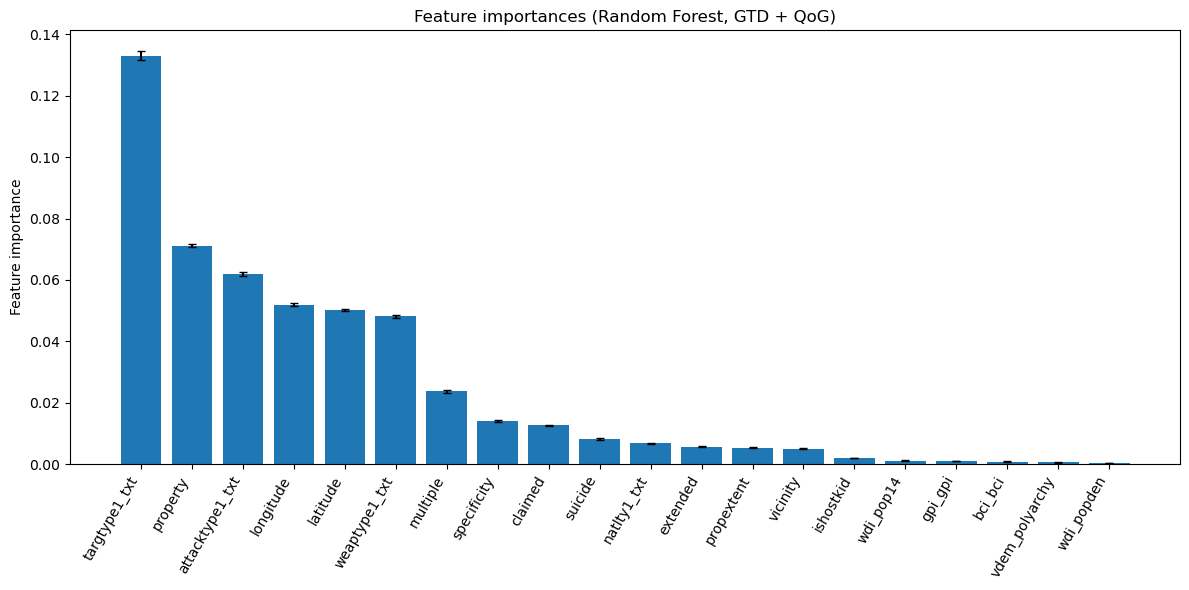

In [17]:
# Plot extended RF feature importances

plot_df = importance_df_ext.head(20)

# Daten vorbereiten
features = plot_df["feature"]
importances = plot_df["importance"]
errors = plot_df["importance_std"]

# Plot
plt.figure(figsize=(12, 6))

plt.bar(
    features,
    importances,
    yerr=errors,
    capsize=3
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Feature importance")
plt.title("Feature importances (Random Forest, GTD + QoG)")

plt.tight_layout()
plt.show()

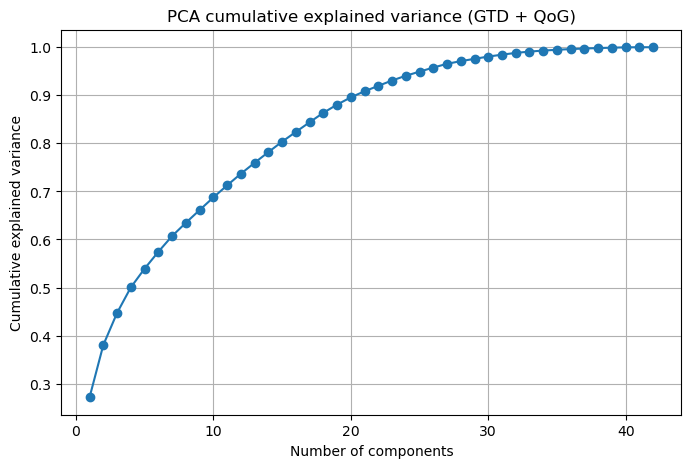

In [18]:
# PCA to determine ideal number of features

X_pca_ext = X_rf_ext.copy()

# Falls noch doppelte Spalten vorhanden sind
X_pca_ext = X_pca_ext.loc[:, ~X_pca_ext.columns.duplicated()]

num_cols = X_pca_ext.select_dtypes(include=["number"]).columns
cat_cols = X_pca_ext.select_dtypes(include=["object"]).columns

# Missing Values behandeln
X_pca_ext[num_cols] = X_pca_ext[num_cols].fillna(X_pca_ext[num_cols].median())
X_pca_ext[cat_cols] = X_pca_ext[cat_cols].fillna("Unknown")

# Kategoriale Variablen temporär numerisch codieren
for col in cat_cols:
    X_pca_ext[col] = pd.factorize(X_pca_ext[col])[0]

# Skalieren für PCA
scaler = StandardScaler()
X_scaled_ext = scaler.fit_transform(X_pca_ext)

# PCA
pca_ext = PCA()
pca_ext.fit(X_scaled_ext)

explained_variance_ext = np.cumsum(pca_ext.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance_ext) + 1),
    explained_variance_ext,
    marker="o"
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance (GTD + QoG)")
plt.grid()
plt.show()

In [19]:
# determine final feature set

T = 32

features_to_exclude_from_model = [
    "target1",
    "propcomment",
    "summary"
]

ranked_features_ext_filtered = [
    feature for feature in ranked_features_ext
    if feature not in features_to_exclude_from_model
]

# Duplikate entfernen, aber Ranking-Reihenfolge behalten
ranked_features_ext_filtered_unique = list(dict.fromkeys(ranked_features_ext_filtered))

selected_features_ext = ranked_features_ext_filtered_unique[:T]

print("Selected features:")
print(selected_features_ext)
print("Number of selected features:", len(selected_features_ext))

X_model = X_train.loc[:, ~X_train.columns.duplicated()]
X_model = X_model[selected_features_ext].copy()

y_model = y_train.copy()

print("X_model shape:", X_model.shape)
print("y_model shape:", y_model.shape)

Selected features:
['targtype1_txt', 'property', 'attacktype1_txt', 'longitude', 'latitude', 'weaptype1_txt', 'multiple', 'specificity', 'claimed', 'suicide', 'natlty1_txt', 'extended', 'propextent', 'vicinity', 'ishostkid', 'wdi_pop14', 'gpi_gpi', 'bci_bci', 'vdem_polyarchy', 'wdi_popden', 'wdi_unempilo', 'wdi_pop65', 'wdi_gdpgr', 'wdi_pop', 'wdi_birth', 'wdi_afp', 'country_txt', 'wdi_brdeath', 'wdi_lifexp', 'bicc_gmi', 'mad_gdppc', 'vdem_corr']
Number of selected features: 32
X_model shape: (61611, 32)
y_model shape: (61611,)


In [20]:
# Preprocessing for selected features (imputaton here and not earlier to prevent data leakage)

num_cols_model = X_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols_model = X_model.select_dtypes(include=["object"]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_model = ColumnTransformer([
    ("num", num_pipeline, num_cols_model),
    ("cat", cat_pipeline, cat_cols_model)
])

In [21]:
# XGBoost pipeline

from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor_model),

    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1
    ))
])

print(xgb_pipeline)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['property', 'longitude',
                                                   'latitude', 'multiple',
                                                   'specificity', 'claimed',
                                                   'suicide', 'extended',
                                                   'propextent', 'vicinity',
                                                   'ishostkid', 'wdi_pop14',
                                                   'gpi_gpi', 'bci_bci',
                                                   'vdem_polyarchy',
                                                   'wdi_popden', 'wdi_unempilo',
                                                

In [22]:
# hyperparameter tuning (practical replication of GA-XGBoost)

def gmean_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

gmean_scorer = make_scorer(gmean_score)

# Intervalle exakt wie in Table 4 des Artikels
param_dist = {
    "model__n_estimators": randint(10, 1000),
    "model__learning_rate": uniform(0.01, 0.99),
    "model__max_depth": randint(1, 15),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0.1, 0.9),
    "model__subsample": uniform(0.1, 0.9),
    "model__colsample_bytree": uniform(0.1, 0.9),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy":  "accuracy",
    "precision": "precision",
    "recall":    "recall",
    "f1":        "f1",
    "roc_auc":   "roc_auc",
    "gmean":     gmean_scorer
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring=scoring,
    refit="f1",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    return_train_score=False
)


random_search.fit(X_model, y_model)

print("Best parameters:")
print(random_search.best_params_)

print(f"\nBest CV F1-score: {random_search.best_score_:.4f}")

best_index = random_search.best_index_

print("\nCross-validated performance of best model:")
for metric in scoring:
    mean_score = random_search.cv_results_[f"mean_test_{metric}"][best_index]
    std_score = random_search.cv_results_[f"std_test_{metric}"][best_index]
    print(f"{metric}: {mean_score:.4f} ± {std_score:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits


c:\Users\lydia\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:36:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters:
{'model__colsample_bytree': np.float64(0.31238642777406017), 'model__gamma': np.float64(0.3304614904851916), 'model__learning_rate': np.float64(0.050029253643047035), 'model__max_depth': 10, 'model__min_child_weight': 3, 'model__n_estimators': 584, 'model__subsample': np.float64(0.9061872361061675)}

Best CV F1-score: 0.8823

Cross-validated performance of best model:
accuracy: 0.8481 ± 0.0042
precision: 0.8588 ± 0.0028
recall: 0.9073 ± 0.0045
f1: 0.8823 ± 0.0033
roc_auc: 0.9152 ± 0.0034
gmean: 0.8239 ± 0.0043


In [ ]:
# =========================================
# 1) Finale Evaluation des GA-XGBoost auf Testdaten
# =========================================
best_xgb = random_search.best_estimator_

expected_features = list(best_xgb.feature_names_in_)

X_test_final = X_test.loc[:, ~X_test.columns.duplicated()]
X_test_final = X_test_final.reindex(columns=expected_features)

y_pred = best_xgb.predict(X_test_final)
y_prob = best_xgb.predict_proba(X_test_final)[:, 1]

print(list(X_test_final.columns) == list(best_xgb.feature_names_in_))

# X_test_final = X_test[selected_features_ext].copy()  
# X_test_final = X_test_final[X_model.columns]
# y_pred = random_search.predict(X_test_final)
# y_prob = random_search.predict_proba(X_test_final)[:, 1]

print("\nFinale Evaluation GA-XGBoost auf Testdaten:")
print(classification_report(y_test, y_pred, target_names=["Keine Opfer", "Opfer"]))  # ← ytest → y_test
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")  # ← ytest → y_test

In [ ]:
# =========================================
# 2) Error Analysis: Confusion Matrix & Performance by Country
# =========================================

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Casualties", "Casualties"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: XGBoost, 32 Features")
plt.tight_layout()
plt.savefig("confusion_matrix_thirtytwo_features.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Error analysis by country ---
# country_txt is still available in X_test (not yet restricted to the final 32 model features)
error_df = pd.DataFrame({
    "country_txt": X_test["country_txt"].values,
    "y_true": y_test.values,
    "y_pred": y_pred
})
error_df["correct"] = (error_df["y_true"] == error_df["y_pred"]).astype(int)

# only consider countries with a reasonable number of test observations
min_obs = 30
country_counts = error_df["country_txt"].value_counts()
countries_enough_obs = country_counts[country_counts >= min_obs].index

country_accuracy = (
    error_df[error_df["country_txt"].isin(countries_enough_obs)]
    .groupby("country_txt")["correct"]
    .mean()
    .sort_values()
)

print(f"Countries with at least {min_obs} test observations: {len(countries_enough_obs)}")
print("\nLowest accuracy (worst-performing countries):")
print(country_accuracy.head(10))
print("\nHighest accuracy (best-performing countries):")
print(country_accuracy.tail(10))

# overall accuracy for comparison
overall_accuracy = error_df["correct"].mean()
print(f"\nOverall test accuracy: {overall_accuracy:.4f}")

plt.figure(figsize=(10, 6))
country_accuracy.head(10).plot(kind="barh", color="indianred")
plt.axvline(overall_accuracy, color="black", linestyle="--", label=f"Overall accuracy ({overall_accuracy:.2f})")
plt.xlabel("Accuracy")
plt.title(f"10 Countries with Lowest Prediction Accuracy (min. {min_obs} test cases)")
plt.legend()
plt.tight_layout()
plt.savefig("error_analysis_country_lowest_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
cv_compare = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "GBDT": Pipeline([                          # ← GBDT statt XGBoost
        ("preprocessing", preprocessor_model),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor_model),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ])
}

results = {}

for name, pipeline in models.items():
    print(f"\nTrainiere {name}...")
    cv_res = cross_validate(
        pipeline,
        X_model,
        y_model,
        cv=cv_compare,
        scoring=scoring,
        n_jobs=-1
    )
    results[name] = {
        metric: cv_res[f"test_{metric}"].mean()
        for metric in scoring
    }
    print(f"  F1:     {results[name]['f1']:.4f}")
    print(f"  AUC:    {results[name]['roc_auc']:.4f}")
    print(f"  Recall: {results[name]['recall']:.4f}")

# GA-XGBoost Ergebnisse hinzufügen
best_index = random_search.best_index_
results["GA-XGBoost"] = {
    metric: random_search.cv_results_[f"mean_test_{metric}"][best_index]
    for metric in scoring
}

In [ ]:
# Ergebnistabelle
results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "recall", "precision", "f1", "roc_auc", "gmean"]]
results_df.columns = ["Accuracy", "Sensitivity", "Precision", "F1-score", "AUC", "G-mean"]
results_df = results_df.round(4)

print("\nVergleich aller Modelle (10-fold CV):")
print(results_df.to_string())
results_df.to_csv("model_comparison_extended.csv")

In [ ]:
# Finale Evaluation aller Modelle auf Testset
X_test_final = X_test[selected_features_ext].copy()  # ← Fix!

print("\nFinale Evaluation auf Testset:")
print("="*60)

for name, pipeline in models.items():
    pipeline.fit(X_model, y_model)
    y_pred_test = pipeline.predict(X_test_final)
    y_prob_test = pipeline.predict_proba(X_test_final)[:, 1]
    auc = roc_auc_score(y_test, y_prob_test)
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred_test,
          target_names=["Keine Opfer", "Opfer"]))
    print(f"AUC: {auc:.4f}")

In [ ]:
best_xgb = random_search.best_estimator_

X_test_preprocessed = best_xgb.named_steps["preprocessing"].transform(X_test_final)

ohe_feature_names = (
    best_xgb.named_steps["preprocessing"]
    .named_transformers_["cat"]
    .named_steps["ohe"]
    .get_feature_names_out(cat_cols_model)
)

all_feature_names = num_cols_model + list(ohe_feature_names)

if hasattr(X_test_preprocessed, "toarray"):
    X_test_preprocessed = X_test_preprocessed.toarray()

xgb_model = best_xgb.named_steps["model"]

dmatrix = xgb.DMatrix(
    X_test_preprocessed,
    feature_names=all_feature_names
)

shap_contribs = xgb_model.get_booster().predict(
    dmatrix,
    pred_contribs=True
)

shap_values = shap_contribs[:, :-1]

# --- NEU: SHAP-Werte auf Original-Features aggregieren ---
ohe_col_to_original = {}
for orig_col in cat_cols_model:
    for ohe_col in ohe_feature_names:
        if ohe_col.startswith(orig_col + "_"):
            ohe_col_to_original[ohe_col] = orig_col

original_features = num_cols_model + cat_cols_model
shap_aggregated = np.zeros((shap_values.shape[0], len(original_features)))

for i, feat in enumerate(original_features):
    if feat in num_cols_model:
        col_idx = all_feature_names.index(feat)
        shap_aggregated[:, i] = shap_values[:, col_idx]
    else:
        ohe_indices = [
            j for j, name in enumerate(all_feature_names)
            if ohe_col_to_original.get(name) == feat
        ]
        shap_aggregated[:, i] = shap_values[:, ohe_indices].sum(axis=1)
# --- ENDE NEU ---

print("shap_aggregated shape:", shap_aggregated.shape)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_aggregated,
    pd.DataFrame(shap_aggregated, columns=original_features),
    feature_names=original_features,
    max_display=32, 
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary_plot_thirtytwo_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Anzahl Zeilen im Plot:", len(original_features))
print("SHAP Plot gespeichert als shap_summary_plot_thirtytwo_features.png")

print("Anzahl Zeilen im Plot:", len(original_features))

True
